# Curvas de Output — EGOFET

Análisis de curvas $I_{DS}$ vs $V_{DS}$ a diferentes $V_{GS}$ constantes.
Aquí observamos las regiones lineal y de saturación del transistor.

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.readers import read_hdf5, list_measurements
from src.plotting import plot_output, plot_output_multi

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data/raw/2026-06-26_test1.hdf5')
OUT_DIR = os.path.join(PROJECT_ROOT, 'output')
os.makedirs(OUT_DIR, exist_ok=True)

measurements = read_hdf5(DATA_PATH)
output_ms = {n: m for n, m in measurements.items() if m.mode == 'output'}
display(list_measurements(output_ms))

,name,mode,batch,device,n_points,columns
0,Batch1_Dispositivo1_Output1_00,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
1,Batch1_Dispositivo1_Output2_00,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
2,Batch1_Dispositivo2_Output_00,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
3,Batch1_Dispositivo2_Output_01,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
4,Batch1_Dispositivo2_Output_03,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
5,Batch1_Dispositivo2_Transfer2_01,output,Batch1,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
6,Batch2_Dispositivo1_Output_01,output,Batch2,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
7,Batch2_Dispositivo1_Output_02,output,Batch2,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
8,Batch2_Dispositivo1_Output_03,output,Batch2,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"
9,Batch2_Dispositivo1_Output_04,output,Batch2,,644,"[V_DS, V_GS, I_DS, I_GS, time, curve, timestamp]"


## Batch 3 — Dispositivo 1

Barrido de $V_{DS}$ de 0 V a −0.4 V para $V_{GS}$ desde +0.2 V hasta −0.4 V.

In [3]:
mo = measurements['Batch3_Dispositivo1_Output_00']
print(mo)
print('V_GS values:', sorted(mo.data['V_GS'].unique()))

Measurement('Batch3_Dispositivo1_Output_00', mode='output', 644 points)
V_GS values: [np.float64(-0.4), np.float64(-0.30000000000000004), np.float64(-0.20000000000000007), np.float64(-0.10000000000000009), np.float64(-1.1102230246251565e-16), np.float64(0.09999999999999987), np.float64(0.19999999999999984)]


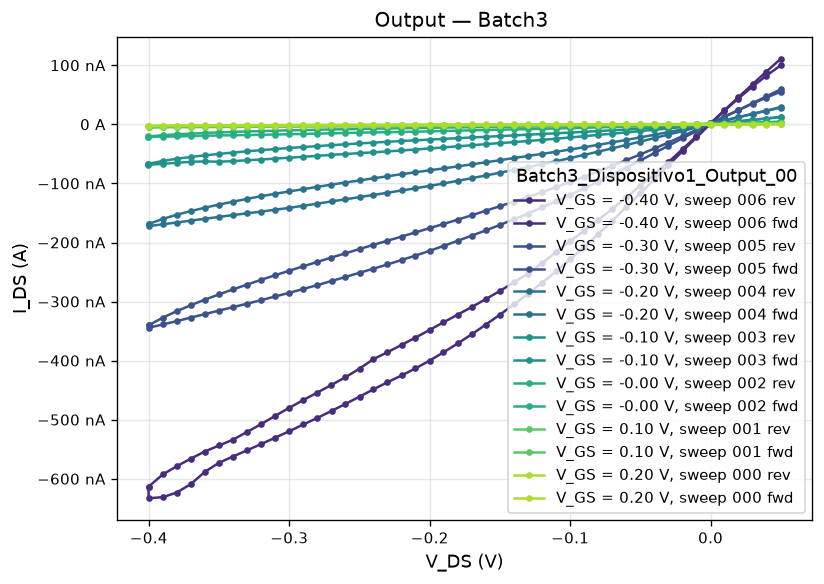

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_output(mo, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'output_curves.png'), dpi=150, bbox_inches='tight')

## Todas las curvas output

/home/dibarra/Documents/egofets-project/src/plotting.py:278: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/dibarra/Documents/egofets-project/src/plotting.py:278: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


/home/dibarra/Documents/egofets-project/src/plotting.py:278: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/dibarra/Documents/egofets-project/src/plotting.py:278: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


/home/dibarra/Documents/egofets-project/src/plotting.py:278: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/dibarra/Documents/egofets-project/src/plotting.py:278: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


/home/dibarra/Documents/egofets-project/src/plotting.py:278: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/dibarra/Documents/egofets-project/src/plotting.py:278: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


/home/dibarra/Documents/egofets-project/src/plotting.py:278: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


/home/dibarra/Documents/egofets-project/src/plotting.py:278: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()
/home/dibarra/Documents/egofets-project/src/plotting.py:394: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


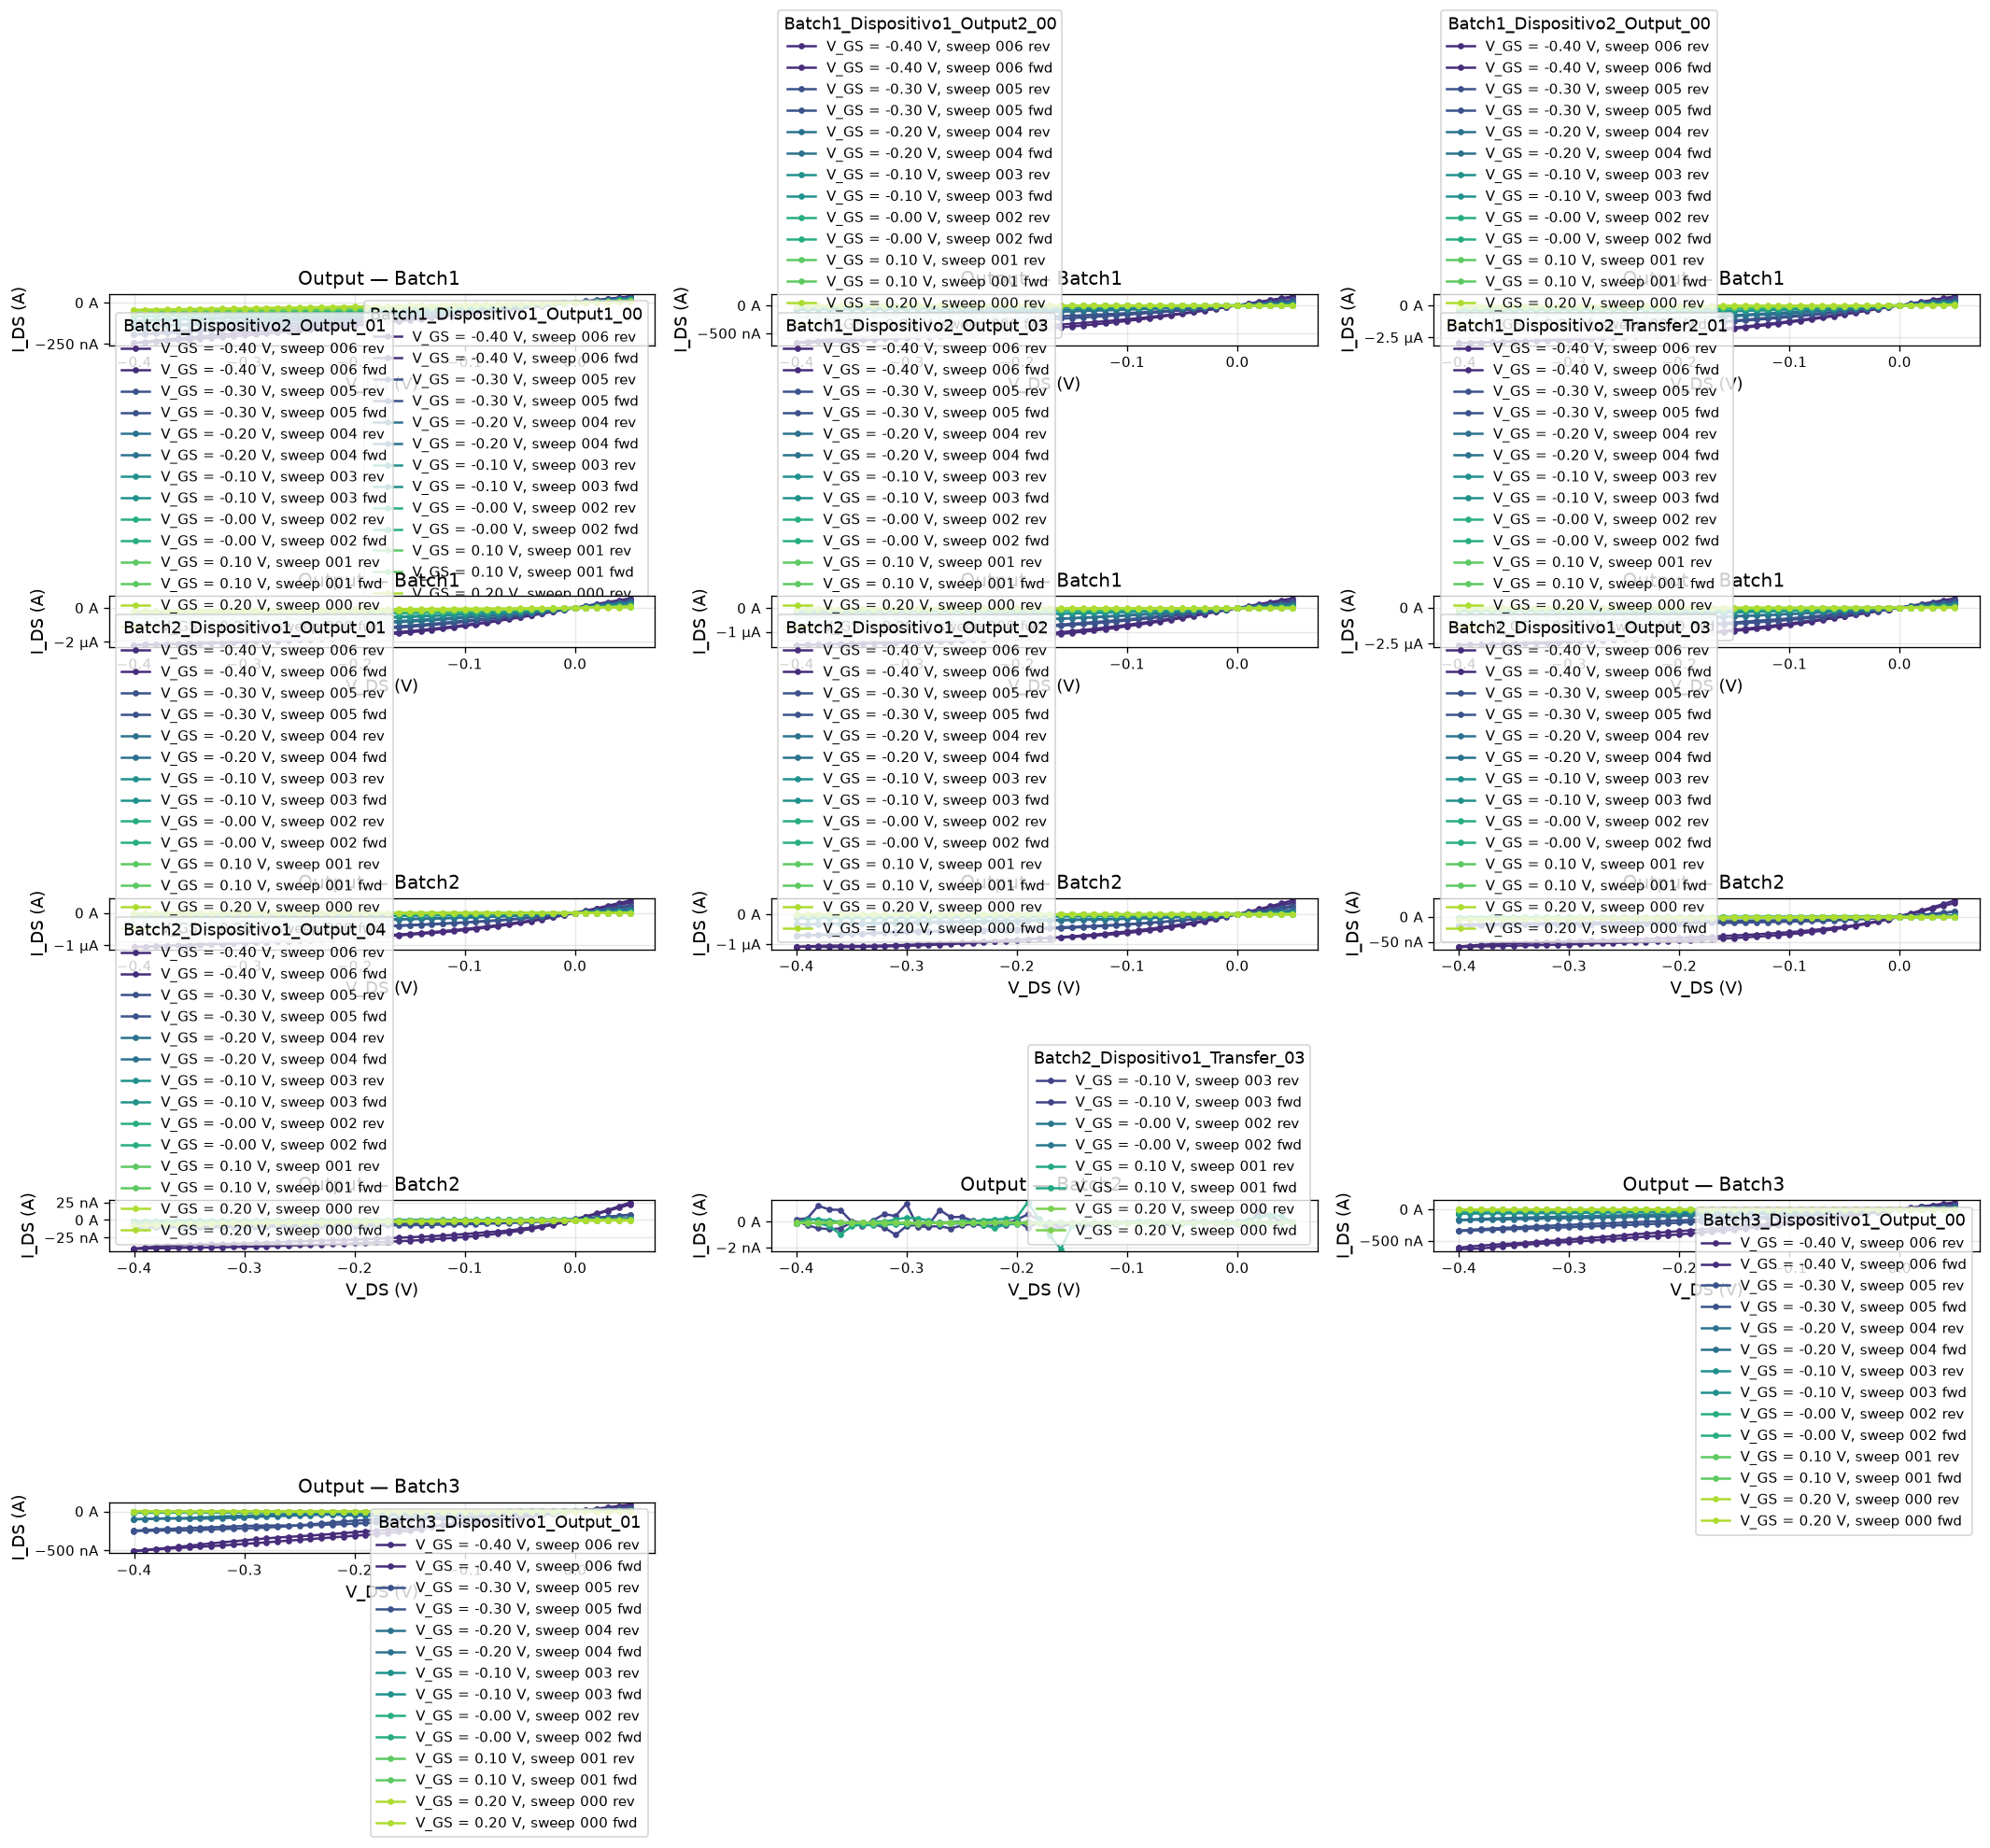

In [5]:
fig, _ = plot_output_multi(measurements, ncols=3, figsize=(18, 12))
plt.savefig(os.path.join(OUT_DIR, 'output_all.png'), dpi=150, bbox_inches='tight')

---
### Interpretación
- **Región lineal** ($V_{DS}$ pequeño): $I_{DS} \propto V_{DS}$.
- **Región de saturación** ($V_{DS}$ grande): estrangulamiento del canal.
- El incremento de $|I_{DS}|$ con $|V_{GS}|$ confirma modulación de compuerta.